In [ ]:
"""
LangGraph workflow for the Fraud Investigation Copilot.

Build order (deliberate): score_node + branch first, tested in isolation.
investigate_node, report_node, and the HITL gate are added in later tasks
once this foundation is confirmed working.
"""

import uuid
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver  # swap for SqliteSaver later (Task 9)
from langsmith import traceable
from state import InvestigationState
from scoring import Transaction, score_transaction
from history_store import get_account_history, update_score
from knowledge_base import load_or_build_vector_db
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from scoring import check_transaction_fraud
from knowledge_base import search_fraud_patterns
from tools import get_account_history as get_account_history_tool
from langgraph.prebuilt import ToolNode, tools_condition
from langchain.messages import SystemMessage, HumanMessage
load_dotenv()


model = ChatGoogleGenerativeAI(
    model="gemma-4-26b-a4b-it",
    temperature=0.8,  # Gemini 3.0+ defaults to 1.0
)

tools = [get_account_history_tool, search_fraud_patterns, check_transaction_fraud]

SYSTEM_PROMPT = """
You are a Senior Fraud Investigation Copilot. Your objective is to investigate financial transactions that have been flagged by our XGBoost machine learning model. 

You have access to the flagged transaction details and its initial fraud score. You must act as a detective to determine WHY the transaction was flagged and whether it constitutes genuine fraud or a false positive.

### Available Tools:
1. `get_account_history`: Use this to pull the last 50 transactions of either the sender or the receiver. 
   - Call this if the ML model indicates "receiver_degree" or "velocity_score" as top contributing features.
   - Look for signs of mule accounts (new accounts receiving many transfers) or account takeovers (sudden spikes in spending).
2. `search_fraud_patterns`: Use this to query the vector database of known fraud typologies. 
   - Call this if the transaction pattern is ambiguous or if you need precedent for specific merchant categories or geographic anomalies.

### Investigation Protocol:
1. Analyze the Context: Review the transaction details and the specific features that drove the high fraud probability score.
2. Gather Evidence: You MUST use the available tools to gather more context. Do not guess. If the sender's history wasn't enough to clear the flag, check the receiver's history.
3. Synthesize: Compare the transaction against the retrieved history and known fraud patterns. 
4. Formulate a Conclusion: Determine your findings. 

### Output Generation:
Once you have finished using tools and gathering evidence, write a concise, evidence-based Investigation Report. Do not use formatting tools like markdown tables unless absolutely necessary for clarity; stick to clear, logical prose. Highlight the most suspicious elements and recommend a final action (Clear or Escalate to Human).
"""

llm_with_tools = model.bind_tools(tools)

# ---------------------------------------------------------------------
# score_node: deterministic, no LLM involved. Pulls sender history,
# scores the transaction, writes the score into state, and persists
# the score to the DB as a side effect.
# ---------------------------------------------------------------------
@traceable
def score_node(state: InvestigationState) -> InvestigationState:
    txn_dict = state["transaction"]
    txn = Transaction(**txn_dict)

    sender_history = get_account_history(txn.sender_account, as_sender=True)
    fraud_score = score_transaction(txn, sender_history)

    # Side effect: persist the score against the transaction row.
    # Nodes are allowed DB side effects — only investigation LOGIC flows
    # through state, per our earlier design.
    update_score(
        transaction_id=txn_dict["transaction_id"],
        fraud_probability=fraud_score["fraud_probability"],
        is_flagged=fraud_score["is_flagged"],
    )

    return {**state, "fraud_score": fraud_score}


# ---------------------------------------------------------------------
# Conditional routing: only branch that exists right now.
# ---------------------------------------------------------------------
@traceable
def route_after_scoring(state: InvestigationState) -> str:
    return "investigate_node" if state["fraud_score"]["is_flagged"] else END


# ---------------------------------------------------------------------
# Placeholder nodes — stubbed so the graph is runnable end-to-end now,
# but these are NOT the real implementations. Replace in later tasks.
# ---------------------------------------------------------------------
@traceable
def investigate_node(state: InvestigationState) -> InvestigationState:
    transaction = state["transaction"]
    fraud_score = state["fraud_score"]

    if not state["messages"]:
        # First call: no prior conversation yet, build it from scratch.
        conversation = [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(
                content=f"Investigate the following flagged transaction: {transaction} with fraud score: {fraud_score}"
            ),
        ]
    else:
        # Subsequent calls: state["messages"] already contains the system
        # prompt, human message, prior AI tool calls, and the ToolMessage
        # results the "tools" node appended — reuse it, don't rebuild it.
        conversation = state["messages"]

    response = llm_with_tools.invoke(conversation)

    return {
        **state,
        "messages": [response],
        "iteration_count": state["iteration_count"] + 1,
    }
@traceable
def route_after_investigate(state: InvestigationState) -> str:
    if state["iteration_count"] >= 4:  # your cap, e.g. 4 rounds
        print(f"[route_after_investigate] iteration_count={state['iteration_count']}")
        return END
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tools"
    return END


tool_node = ToolNode(tools)


/home/arjunverma/miniconda3/envs/common-env/lib/python3.12/pickle.py:1760: UserWarning: [21:19:31] WARNING: /__w/xgboost/xgboost/src/gbm/gbtree.cc:443: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  setstate(state)
/home/arjunverma/miniconda3/envs/common-env/lib/python3.12/pickle.py:1760: UserWarning: [21:19:31] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  setstate(state)
/home/arjunverma/miniconda3/envs/common-env/lib/python3.12/pickle.py:1760: UserWarning: [21:19:31] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  setstate(state)
/home/arjunverma/miniconda3/envs/common-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/arjunverma

No documents found in the vector database. Loading and processing documents...


ValueError: File path data/knowledge_base.pdf is not a valid file or url

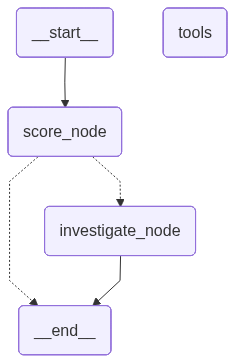

In [ ]:
# ---------------------------------------------------------------------
# Build the graph
# ---------------------------------------------------------------------
def build_graph():
    builder = StateGraph(InvestigationState)

    builder.add_node("score_node", score_node)
    builder.add_node("investigate_node", investigate_node)  # stub for now
    builder.add_node("tools", tool_node)

    builder.add_edge(START, "score_node")
    builder.add_conditional_edges(
        "score_node",
        route_after_scoring,
        {"investigate_node": "investigate_node", END: END},
    )
    builder.add_conditional_edges("investigate_node", route_after_investigate)
    builder.add_edge("tools", "investigate_node")  # route to tools node for tool invocation

    # Checkpointer needed even at this stage if you want to test resuming;
    # harmless to include now, becomes load-bearing once interrupt() (Task 7) exists.
    checkpointer = MemorySaver()
    return builder.compile(checkpointer=checkpointer)


graph = build_graph()
graph


In [ ]:


# ---------------------------------------------------------------------
# Manual test harness — run this file directly to sanity-check the
# score_node + branch in isolation, per the recommended build order.
# ---------------------------------------------------------------------
if __name__ == "__main__":
    sample_transaction = {
        "transaction_id": str(uuid.uuid4()),
        "sender_account": "ACC1001",
        "receiver_account": "ACC499875",
        "amount": 50.8,
        "timestamp": "2026-07-13T02:15:00",
        "merchant_category": "online",
        "transaction_type": "withdrawal",
        "spending_deviation_score": 3.2,
        "velocity_score": 55.0,
        "geo_anomaly_score": 1.8,
        "ip_address": "10.0.0.1",
        "device_used": "mobile",
        "location": "Tokyo",
        "payment_channel": "wire_transfer",
        "device_hash": "abc123",
        "time_since_last_transaction": -4435.60446271083
    }

    initial_state: InvestigationState = {
        "transaction": sample_transaction,
        "fraud_score": {},
        "account_checks": [],
        "retrieved_patterns": [],
        "account_feedback_history": [],
        "investigation_report": "",
        "human_decision": None,
        "human_notes": None,
        "messages": [],
        "iteration_count": 0,
    }

    config = {"configurable": {"thread_id": sample_transaction["transaction_id"]}}
    result = graph.invoke(initial_state, config=config)

    print("\nFinal state:")
    print("Fraud score:", result["fraud_score"])

In [ ]:
import pandas as pd
import polars as pl
lazy_df = pl.scan_csv("financial_fraud_detection_dataset.csv")
filtered_lazy_df = lazy_df.filter(pl.col("is_fraud") == True).limit(10)
final_df = filtered_lazy_df.collect()

In [ ]:
final_df = final_df.with_columns(pl.col("time_since_last_transaction").cast(pl.Float64))
final_df.head()

transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
str,str,str,str,f64,str,str,str,str,bool,str,f64,f64,i64,f64,str,str,str
"""T107720""","""2023-02-27T09:09:10.721286""","""ACC391250""","""ACC499875""",50.8,"""withdrawal""","""online""","""Tokyo""","""mobile""",true,"""card_not_present""",-4435.604463,-1.18,16,0.51,"""ACH""","""207.94.248.163""","""D9978939"""
"""T114513""","""2023-03-11T04:52:42.790807""","""ACC853799""","""ACC774781""",1099.03,"""deposit""","""grocery""","""Berlin""","""atm""",true,"""card_not_present""",-543.435253,0.18,8,0.47,"""UPI""","""34.66.126.237""","""D9225721"""
"""T121111""","""2023-09-21T23:06:03.802962""","""ACC743015""","""ACC311170""",18.73,"""transfer""","""retail""","""Berlin""","""atm""",true,"""card_not_present""",3339.160882,0.57,10,0.5,"""ACH""","""115.218.159.229""","""D6163373"""
"""T124247""","""2023-03-23T18:47:07.370345""","""ACC693265""","""ACC304655""",1057.66,"""deposit""","""other""","""Singapore""","""mobile""",true,"""card_not_present""",-5616.318212,-0.11,1,0.93,"""ACH""","""102.102.14.51""","""D1201766"""
"""T124325""","""2023-03-01T15:29:39.072741""","""ACC773851""","""ACC321187""",26.36,"""payment""","""other""","""Tokyo""","""pos""",true,"""card_not_present""",-2102.467519,-0.06,7,0.22,"""UPI""","""134.105.153.161""","""D6904335"""


In [ ]:



def workflow_test():
    sample_transaction = {
        "transaction_id": str(uuid.uuid4()),
        "sender_account": "ACC1001",
        "receiver_account": "ACC499875",
        "amount": 50.8,
        "timestamp": "2026-07-13T02:15:00",
        "merchant_category": "online",
        "transaction_type": "withdrawal",
        "spending_deviation_score": 3.2,
        "velocity_score": 55.0,
        "geo_anomaly_score": 1.8,
        "ip_address": "10.0.0.1",
        "device_used": "mobile",
        "location": "Tokyo",
        "payment_channel": "wire_transfer",
        "device_hash": "abc123",
        "time_since_last_transaction": -4435.60446271083
    }

    initial_state: InvestigationState = {
        "transaction": sample_transaction,
        "fraud_score": {},
        "account_checks": [],
        "retrieved_patterns": [],
        "account_feedback_history": [],
        "investigation_report": "",
        "human_decision": None,
        "human_notes": None,
        "messages": [],
        "iteration_count": 0,
    }

    config = {"configurable": {"thread_id": sample_transaction["transaction_id"]}}
    result = graph.invoke(initial_state, config=config)

    print("\nFinal state:")
    print("Fraud score:", result["fraud_score"])



for row in final_df.iter_rows(named=True):
    sample_transaction = {
        "transaction_id": str(uuid.uuid4()),
        "sender_account": row["sender_account"],
        "receiver_account": row["receiver_account"],
        "amount": row["amount"],
        "timestamp": row["timestamp"],
        "merchant_category": row["merchant_category"],
        "transaction_type": row["transaction_type"],
        "spending_deviation_score": row["spending_deviation_score"],
        "velocity_score": row["velocity_score"],
        "geo_anomaly_score": row["geo_anomaly_score"],
        "ip_address": row["ip_address"],
        "device_used": row["device_used"],
        "location": row["location"],
        "payment_channel": row["payment_channel"],
        "device_hash": row["device_hash"],
        "time_since_last_transaction": row["time_since_last_transaction"]
    }

    print("In progress")

    initial_state: InvestigationState = {
        "transaction": sample_transaction,
        "fraud_score": {},
        "account_checks": [],
        "retrieved_patterns": [],
        "account_feedback_history": [],
        "investigation_report": "",
        "human_decision": None,
        "human_notes": None,
        "messages": [],
        "iteration_count": 0,
    }

    print("State created. Invoking graph...")
    config = {"configurable": {"thread_id": sample_transaction["transaction_id"]}}
    result = graph.invoke(initial_state, config=config)

    print("\nFinal state:")
    print("Report:", result["messages"][-1].content)
    break

In progress
State created. Invoking graph...


NameError: name 'vector_db' is not defined

In [6]:
result

{'transaction': {'transaction_id': '7e8ef91b-7ded-4040-a8fb-0a68b23304dc',
  'sender_account': 'ACC391250',
  'receiver_account': 'ACC499875',
  'amount': 50.8,
  'timestamp': '2023-02-27T09:09:10.721286',
  'merchant_category': 'online',
  'transaction_type': 'withdrawal',
  'spending_deviation_score': -1.18,
  'velocity_score': 16,
  'geo_anomaly_score': 0.51,
  'ip_address': '207.94.248.163',
  'device_used': 'mobile',
  'location': 'Tokyo',
  'payment_channel': 'ACH',
  'device_hash': 'D9978939',
  'time_since_last_transaction': -4435.604462710833},
 'fraud_score': {'fraud_probability': 0.3446,
  'is_flagged': True,
  'threshold_used': 0.3384,
  'top_contributing_features': ['device_hash',
   'ip_address',
   'receiver_account',
   'sender_account',
   'time_since_last_transaction']},
 'account_checks': [],
 'retrieved_patterns': [],
 'account_feedback_history': [],
 'investigation_report': '',
 'human_decision': None,
 'human_notes': None,
 'messages': [AIMessage(content=[{'type':

In [19]:
import json
from langsmith import Client

client = Client()

# Your top-level trace/root run ID
trace_id = "019f6a02-fbd3-74b3-9983-1e596ff677fd"

# CRUCIAL: Pass load_child_runs=True to grab the entire tree hierarchy
whole_trace = client.read_run(trace_id, load_child_runs=True)

# Export the entire tree (including child runs) to a JSON file
with open("complete_trace_tree2.json", "w") as f:
    json.dump(whole_trace.dict(), f, indent=4, default=str)


/tmp/ipykernel_9397/4251516253.py:14: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  json.dump(whole_trace.dict(), f, indent=4, default=str)
